In [1]:
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

dataDir = os.path.join("/content/drive/MyDrive/QReaserch/graph_coarsening/graph_coarsening/21_solving-vehicle-routing-problem-and-its-variants-using-quantum-computing_b/results")

data_Christofides_neal = pd.read_csv(os.path.join(dataDir, "neal", "CSPS_csvOutputFile_neal.csv"))
data_Christofides_leap = pd.read_csv(os.path.join(dataDir, "leap", "CSPS_csvOutputFile_leap.csv"))


Mounted at /content/drive


In [58]:
nodes_num4CMT_instance = {'CMT01.xml': 51,
                          'CMT02.xml': 76,
                          'CMT03.xml': 101,
                          'CMT04.xml': 151,
                          'CMT05.xml': 200,
                          'CMT11.xml': 121,
                          'CMT12.xml': 101}

def flatten(x_array):
    """flateen array function"""
    flat = [item for sublist in x_array for item in sublist]
    return flat

def get_relative_values(data):
    """Get the data frame with the row data and calculate the relative cost and evaluation time"""
    cmt_instance_name = []
    ratio_cost = []
    nodes_number = []
    run_number = []
    coarsening_ratio = []

    for run in data['Run Number'].unique():
        for cmt_instance in data['cmtFileName'].unique():
            nodes = nodes_num4CMT_instance[cmt_instance]
            coarsening_ratio.append(data['Coarsening Rate'][(data['Run Number']==run) & (data['cmtFileName']==cmt_instance)].values)
            temp = data['Relative Cost'][(data['Run Number']==run) & (data['cmtFileName']==cmt_instance)].values
            if len(temp) != 0:
              ratio_cost.append(temp/temp[0])
              nodes_number.append([nodes]*len(temp))
              run_number.append([run]*len(temp))
              cmt_instance_name.append([cmt_instance]*len(temp))

    # Get the relative solve time
    ratio_time = []
    for run in data['Run Number'].unique():
        for cmt_instance in data['cmtFileName'].unique():
            temp = data['Solve Time'][(data['Run Number']==run) & (data['cmtFileName']==cmt_instance)].values
            if len(temp) != 0:
              ratio_time.append(temp/temp[0])

    cmt_instance_name = flatten(cmt_instance_name)
    ratio_cost = flatten(ratio_cost)
    nodes_number = flatten(nodes_number)
    run_number = flatten(run_number)
    ratio_time = flatten(ratio_time)
    coarsening_ratio = flatten(coarsening_ratio)

    relative_df = pd.DataFrame(list(zip(cmt_instance_name,coarsening_ratio,nodes_number, run_number,ratio_cost,ratio_time)), 
    columns =['cmtFileName', 'coarsening_ratio','nodes_number','run_number','ratio_cost','ratio_time'])
    return(relative_df)


In [59]:
relative_Christofides_neal_df = get_relative_values(data_Christofides_neal)
relative_Christofides_leap_df = get_relative_values(data_Christofides_leap)

# print(relative_Christofides_neal_df.to_markdown())
# print(relative_Christofides_leap_df.to_markdown())

In [60]:
def plot_results(df, filename):

    ratios = df['coarsening_ratio'].unique()
    ratios = sorted(ratios, reverse=True)
    ratio_label = [str(label) for label in  ratios]
    
    # collecting all the data as function of coarsening ratio
    data_cost = []
    for ratio in ratios:
        data_cost.append(df[df['coarsening_ratio']==ratio].ratio_cost.values)

    # collecting all the data as function of coarsening ratio
    data_time = []
    for ratio in ratios:
        data_time.append(df[df['coarsening_ratio']==ratio].ratio_time.values)

    fig = plt.figure(figsize=(20,6))
    ax = fig.add_subplot(1,2,1)

    ax.boxplot(data_time)

    # axis labels
    ax.set_xticklabels([*ratio_label], fontsize=18)
    ax.yaxis.set_tick_params(labelsize=18)

    # Adding title
    plt.title("Relative Evaluation time Function", fontsize=20)

    plt.ylabel('relative time', fontsize=18)
    plt.xlabel('coarsening ratio', fontsize=18)

    ax = fig.add_subplot(1,2,2)
    # Creating plot
    ax.boxplot(data_cost)

    # axis labels
    ax.set_xticklabels([*ratio_label], fontsize=18)
    ax.yaxis.set_tick_params(labelsize=18)

    # Adding title
    plt.title("Relative Cost Function", fontsize=20)

    plt.ylabel('relative Cost', fontsize=18)
    plt.xlabel('coarsening ratio', fontsize=18)

    plt.savefig(filename)  


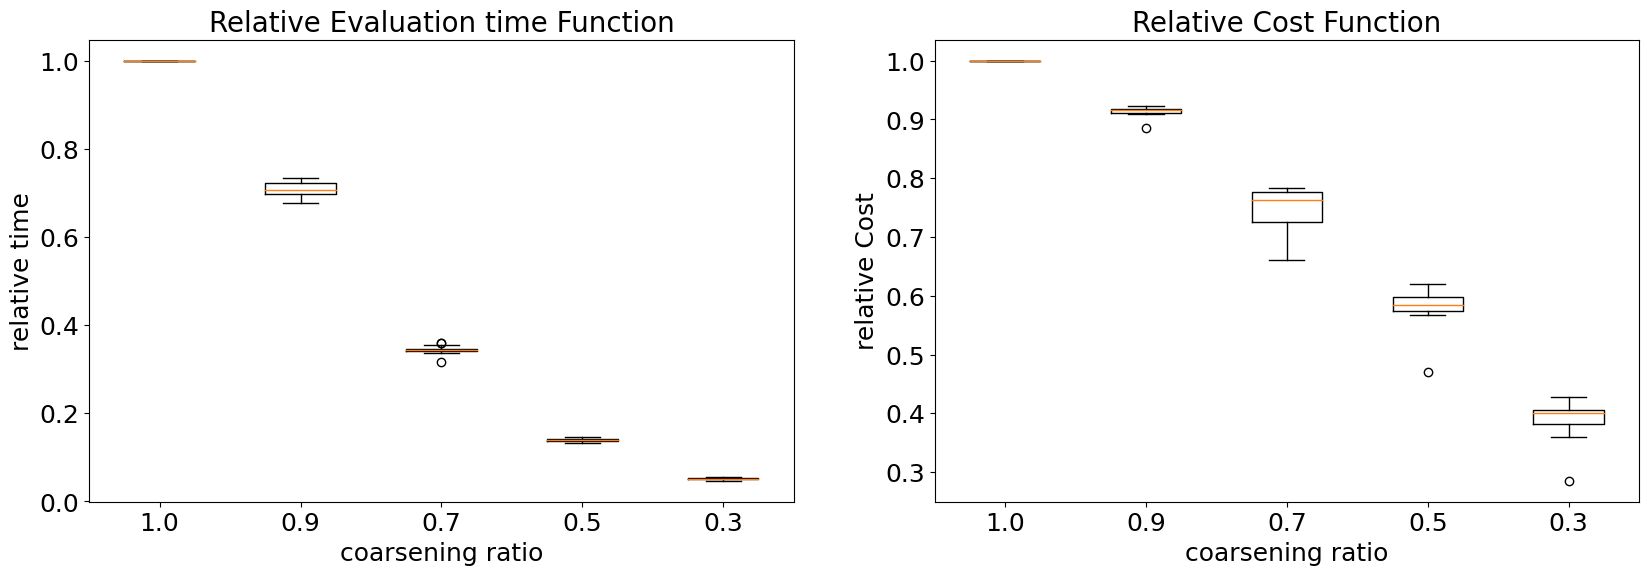

In [61]:
plot_results(relative_Christofides_neal_df, "relative_Christofides_neal_df.pdf")

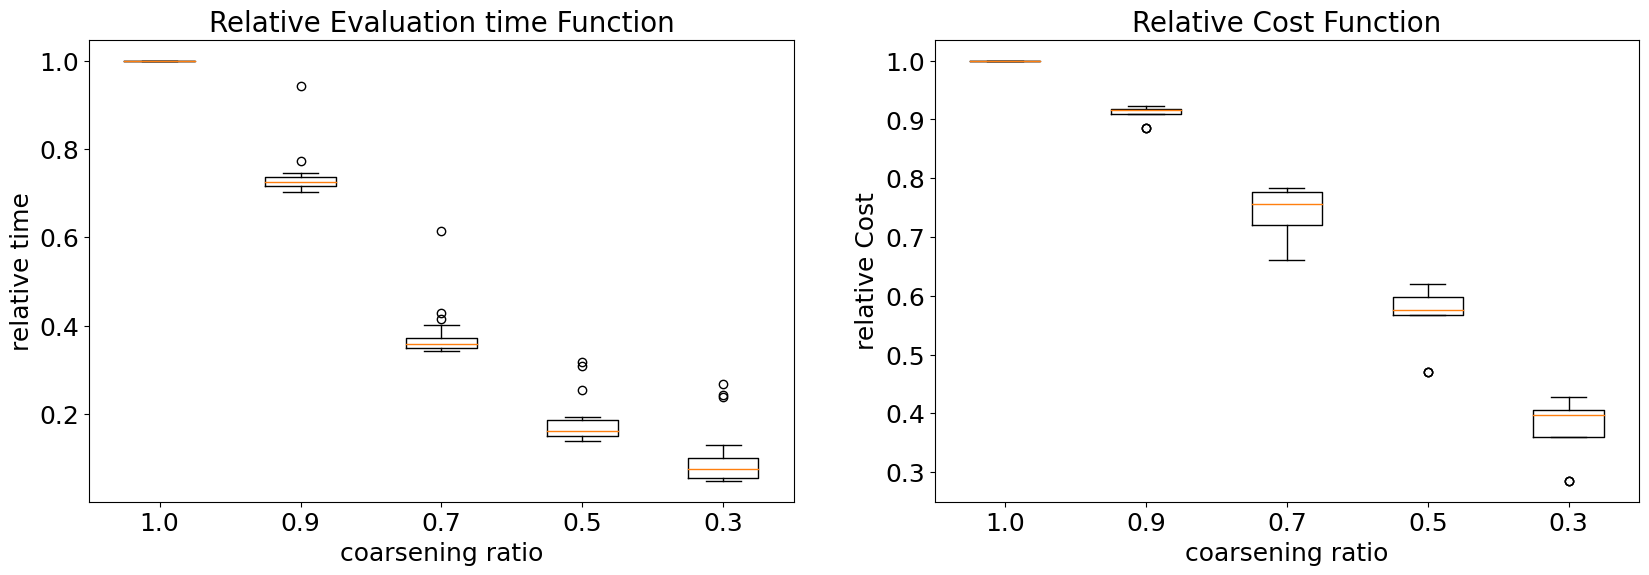

In [62]:

plot_results(relative_Christofides_leap_df, "relative_Christofides_leap_df.pdf")

In [63]:
import seaborn as sns

colors = sns.color_palette("Set1", len(nodes_num4CMT_instance))


def plot_results_scatter(df, filename, colors):

    fig, axs = plt.subplots(1, 2, figsize=(20, 7))

    # Plot for relative time
    ax1 = axs[0]
    for idx, cmt_instance in enumerate(nodes_num4CMT_instance):
        cmt = cmt_instance.replace(".xml", "")
        ax1.scatter(
            df[df["cmtFileName"] == cmt_instance].coarsening_ratio.values,
            df[df["cmtFileName"] == cmt_instance].ratio_time.values,
            color=colors[idx],
            label=f"{cmt}, N = {nodes_num4CMT_instance[cmt_instance]}",
        )
    ax1.legend()
    ax1.xaxis.set_tick_params(labelsize=18)
    ax1.yaxis.set_tick_params(labelsize=18)
    ax1.set_title("Relative Evaluation Time Function", fontsize=20)
    ax1.set_ylabel("Relative Time", fontsize=18)
    ax1.set_xlabel("Coarsening Ratio", fontsize=18)

    # Plot for relative cost
    ax2 = axs[1]
    for idx, cmt_instance in enumerate(nodes_num4CMT_instance):
        cmt = cmt_instance.replace(".xml", "")
        ax2.scatter(
            df[df["cmtFileName"] == cmt_instance].coarsening_ratio.values,
            df[df["cmtFileName"] == cmt_instance].ratio_cost.values,
            color=colors[idx],
            label=f"{cmt}, N = {nodes_num4CMT_instance[cmt_instance]}",
        )
    ax2.legend()
    ax2.xaxis.set_tick_params(labelsize=18)
    ax2.yaxis.set_tick_params(labelsize=18)
    ax2.set_title("Relative Cost Function", fontsize=20)
    ax2.set_ylabel("Relative Cost", fontsize=18)
    ax2.set_xlabel("Coarsening Ratio", fontsize=18)

    plt.tight_layout()
    plt.savefig(filename)

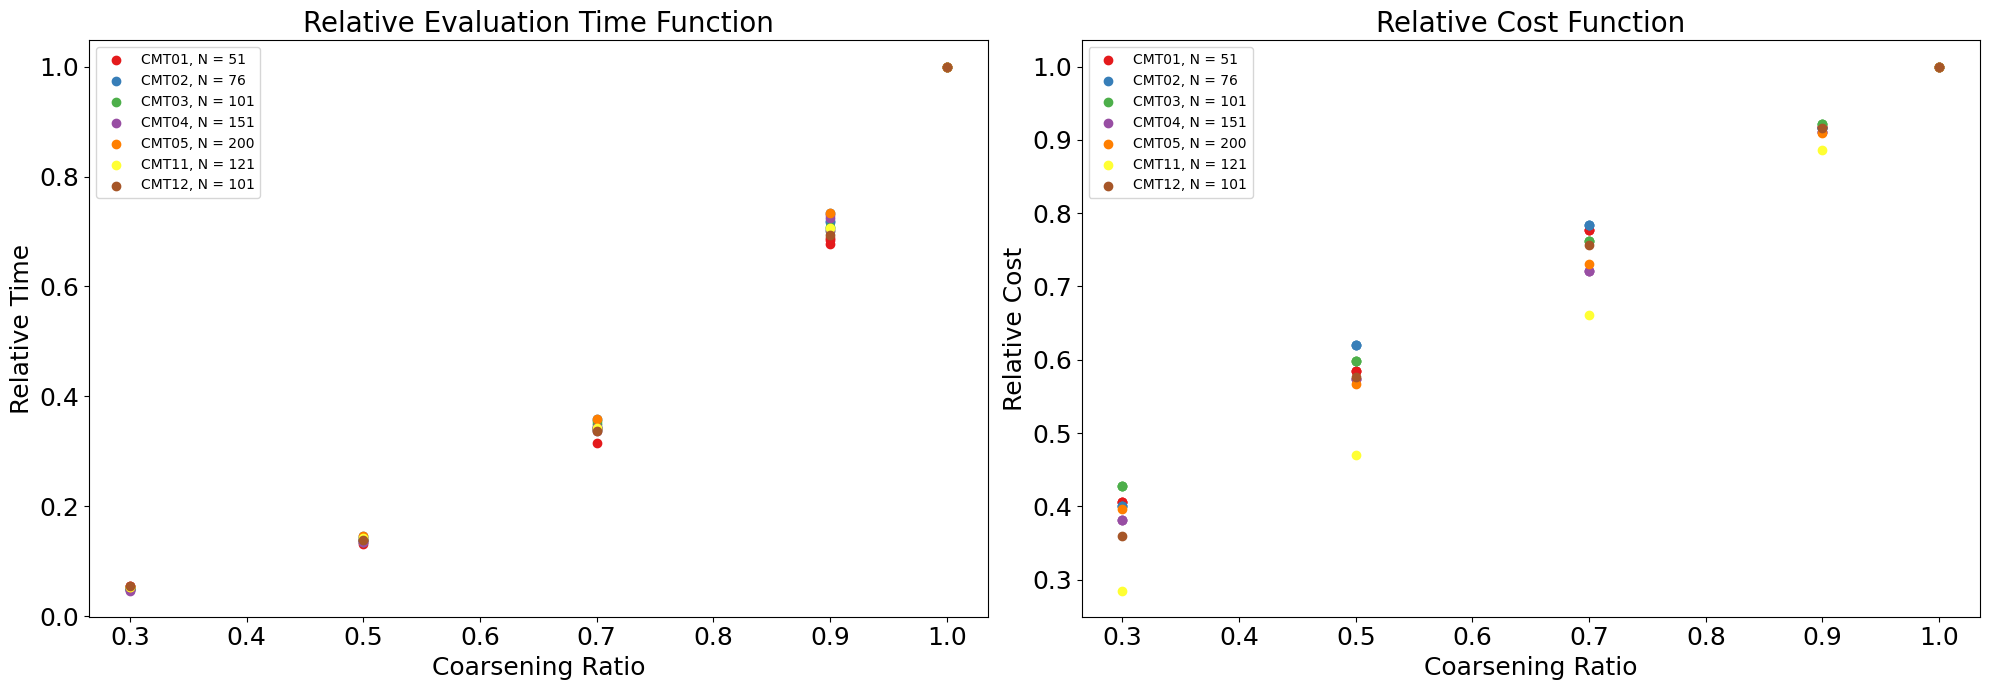

In [64]:
plot_results_scatter(relative_Christofides_neal_df, "relative_Christofides_neal_df_scatter.pdf", colors)

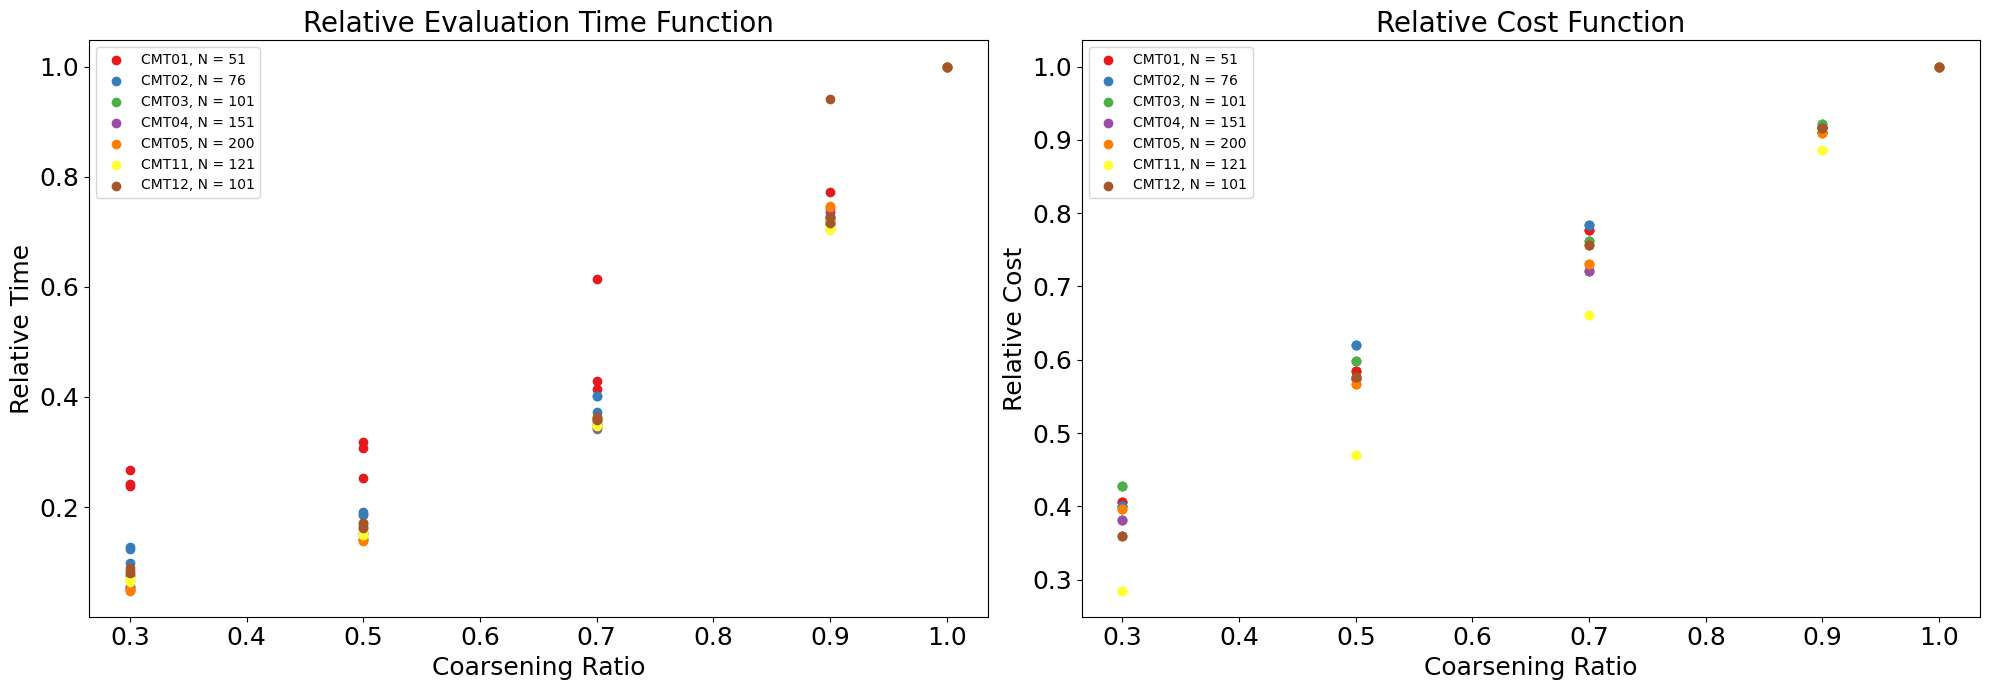

In [65]:
plot_results_scatter(relative_Christofides_leap_df, "relative_Christofides_leap_df_scatter.pdf", colors)

In [66]:
def plot_mean_relative_cost_histogram(df_leap, df_neal, filename):
    # Calculate the mean relative cost for each problem instance for Leap
    mean_solution_cost_leap = df_leap.groupby("cmtFileName")["Relative Cost"].mean()

    # Calculate the mean relative cost for each problem instance for Neal
    mean_solution_cost_neal = df_neal.groupby("cmtFileName")["Relative Cost"].mean()

    sorted_instances_leap = mean_solution_cost_leap.sort_values()
    sorted_instances_neal = mean_solution_cost_neal.sort_values()

    # Generate the subplots
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Subplot for Leap
    ax_leap = axes[0]
    sorted_instances_leap.plot(kind="bar", ax=ax_leap, color=colors)
    ax_leap.set_xlabel("CVRP Instance")
    ax_leap.set_ylabel("Relative Solution Cost")
    ax_leap.set_title("Performance of CSPS (backend: leap) - Mean Relative Cost")
    ax_leap.set_xticklabels(ax_leap.get_xticklabels(), rotation=45)

    # Subplot for Neal
    ax_neal = axes[1]
    sorted_instances_neal.plot(kind="bar", ax=ax_neal,  color=colors)
    ax_neal.set_xlabel("CVRP Instance")
    ax_neal.set_ylabel("Relative Solution Cost")
    ax_neal.set_title("Performance of CSPS (backend: neal) - Mean Relative Cost")
    ax_neal.set_xticklabels(ax_neal.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.savefig(filename)


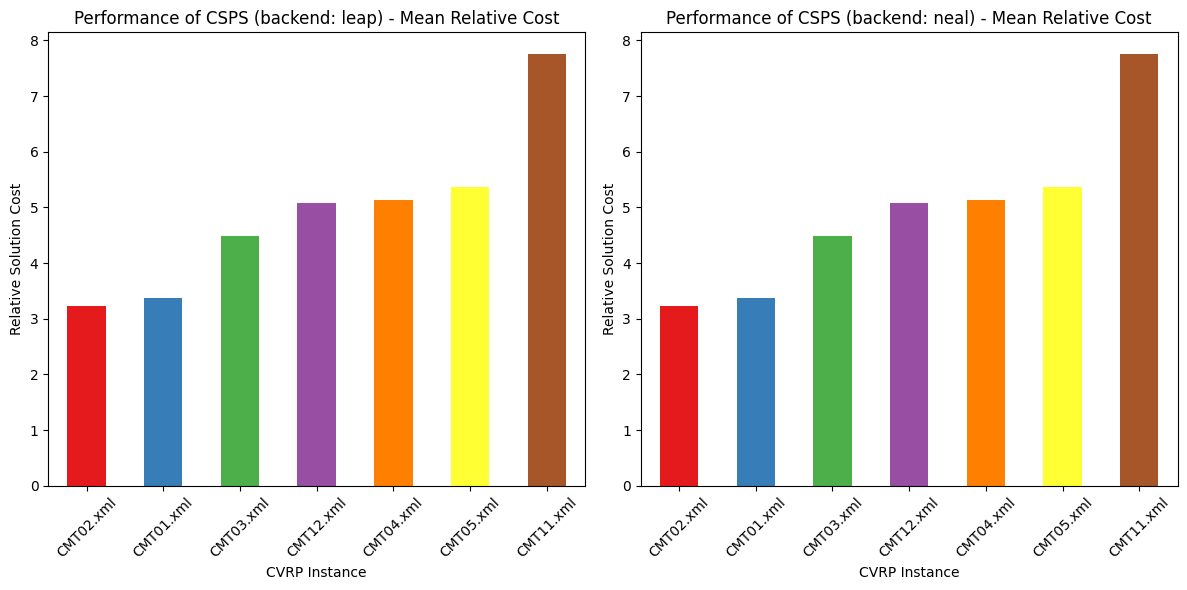

In [67]:
plot_mean_relative_cost_histogram(data_Christofides_leap, data_Christofides_neal, "Christofides_df_mean_relative_cost_histogram.pdf")

In [68]:
# !pip install dwave-ocean-sdk

In [69]:
# from dwave.cloud import Client
# from dwave.cloud.exceptions import SolverError


# def get_dwave_info(df):
#     done = {}

#     for token in ["TODO"]:
#         os.environ["DWAVE_API_TOKEN"] = token
#         client = Client.from_config(token=token)
#         for index, row in df.iterrows():
#             problem_id = row["D-Wave Problem ID"]
#             if problem_id in done:
#                 continue
#             try:
#                 res = client.retrieve_answer(problem_id)
#                 qpu_access_time = res.result()["sampleset"].info["qpu_access_time"]/1000.0
#                 charge_time = res.result()["sampleset"].info["charge_time"]/1000.0
#                 run_time = res.result()["sampleset"].info["run_time"]/1000.0
#                 df.at[index, "qpu_access_time"] = qpu_access_time
#                 df.at[index, "charge_time"] = charge_time
#                 df.at[index, "run_time"] = run_time
#                 done[problem_id] = res.result()["sampleset"].info
#             except SolverError:
#                 df.at[index, "qpu_access_time"] = "N/A"
#                 df.at[index, "charge_time"] = "N/A"
#                 df.at[index, "run_time"] = "N/A"
    
#     return df


In [70]:
dwave_time_info = get_dwave_info(data_Christofides_leap)

<ipython-input-71-343146812c76>:9: FutureWarning: The default value of regex will change from True to False in a future version.
  df["cmtFileName"] = df["cmtFileName"].str.replace(".xml", "")


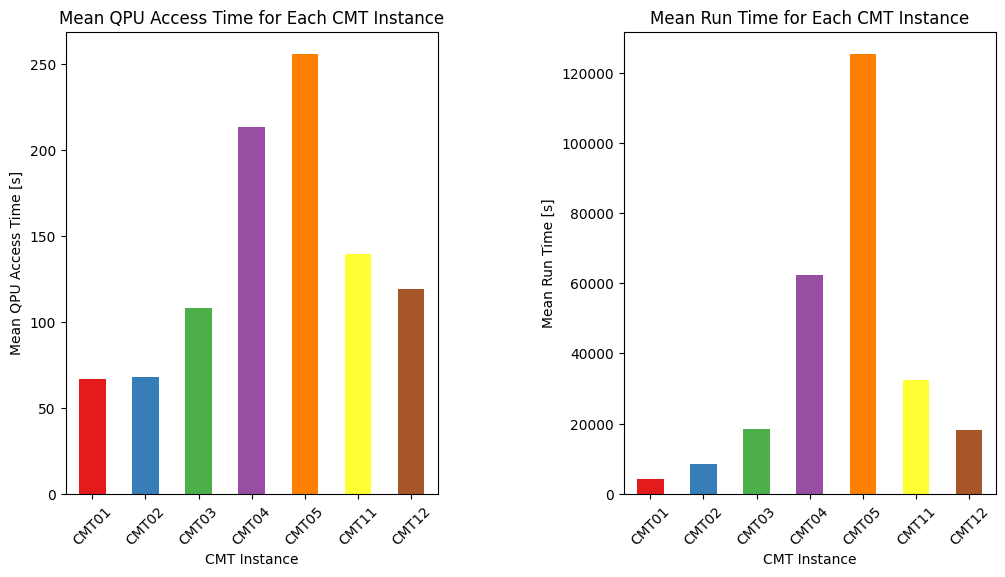

In [71]:
# Read the CSV file
df = pd.read_csv(os.path.join(dataDir, "leap", "CSPS_csvOutputFile_leap_with_qpu_time.csv"))

import pandas as pd
import matplotlib.pyplot as plt


# Remove ".xml" suffix from the cmtFileName column
df["cmtFileName"] = df["cmtFileName"].str.replace(".xml", "")

# Calculate the mean QPU access time and run time for each CMT instance
mean_qpu_time = df.groupby("cmtFileName")["qpu_access_time"].mean()
mean_run_time = df.groupby("cmtFileName")["run_time"].mean()

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot the mean QPU access time
mean_qpu_time.plot(kind="bar", color=colors, ax=ax1)
ax1.set_xlabel("CMT Instance")
ax1.set_ylabel("Mean QPU Access Time [s]")
ax1.set_title("Mean QPU Access Time for Each CMT Instance")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# Plot the mean run time
mean_run_time.plot(kind="bar", color=colors, ax=ax2)
ax2.set_xlabel("CMT Instance")
ax2.set_ylabel("Mean Run Time [s]")
ax2.set_title("Mean Run Time for Each CMT Instance")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

# Adjust the spacing between the subplots
plt.subplots_adjust(wspace=0.5)

# Display the plots
plt.savefig("Christofides_leap_df_qpu_and_run_time.pdf")
